# Step 5: Predict Customer Churn using Random Forest

**Project**: Telecom Customer Churn Analysis  
**Source**: Pivotalstats Portfolio Project  

In this notebook, we develop an end-to-end Machine Learning pipeline using a **Random Forest Classifier** to predict customer churn. 
We train the model on historical customer data (`vw_ChurnData`), evaluate its performance, analyze feature importances, and predict churn on new joiners (`vw_JoinData`) to generate `Predictions.csv`.


### 1. Importing Libraries & Data Load

Import necessary packages for data manipulation, visualization, modeling, and evaluation.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Set visual theme
sns.set_theme(style="whitegrid")

# Load historical customer data (vw_ChurnData)
data_path = os.path.join("..", "data", "processed", "vw_ChurnData.csv")
data = pd.read_csv(data_path)

# Display shape and sample
print(f"Data Shape: {data.shape}")
data.head()


Data Shape: (6007, 32)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,Others,Others
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Others,Others
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


### 2. Data Preprocessing

- Drop non-predictive columns (`Customer_ID`, `Churn_Category`, `Churn_Reason`).
- Encode categorical features using `LabelEncoder`.
- Manually encode target variable `Customer_Status` (`Stayed: 0`, `Churned: 1`).
- Split dataset into 80% train and 20% test sets.

In [2]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features shape: {X.shape}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Target distribution in y_train:")
print(y_train.value_counts())


Features shape: (6007, 28)
X_train: (4805, 28), X_test: (1202, 28)
Target distribution in y_train:
Customer_Status
0    3434
1    1371
Name: count, dtype: int64


### 3. Train Random Forest Model

Initialize and train the `RandomForestClassifier` with `n_estimators=100` and `random_state=42`.

In [3]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4. Evaluate Model

Evaluate predictions against test labels using Confusion Matrix and Classification Report.

In [4]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[790  51]
 [125 236]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       841
           1       0.82      0.65      0.73       361

    accuracy                           0.85      1202
   macro avg       0.84      0.80      0.81      1202
weighted avg       0.85      0.85      0.85      1202



### 5. Feature Selection using Feature Importance

Analyze which features have the greatest influence on customer churn decisions.

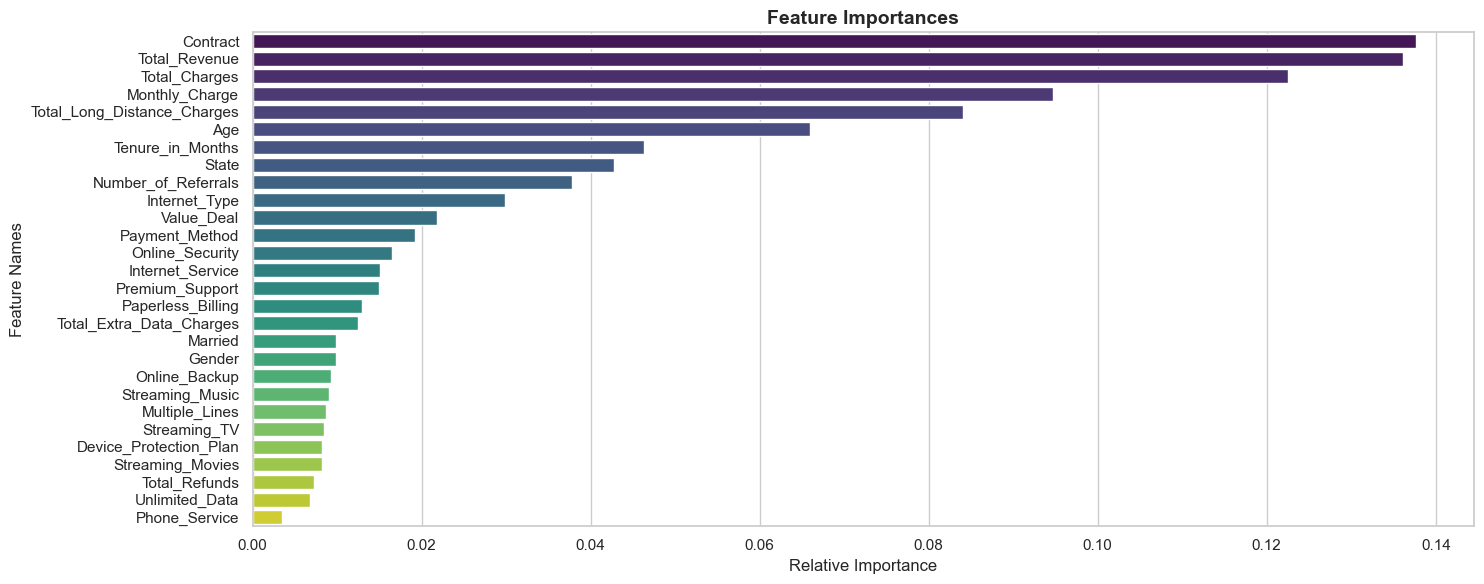

In [5]:
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], hue=X.columns[indices], legend=False, palette="viridis")
plt.title('Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature Names', fontsize=12)
plt.tight_layout()
plt.show()


### 6. Use Model for Prediction on New Data (`vw_JoinData`)

Load newly joined customers (`vw_JoinData`), apply categorical encoding, predict churn probability/status, and isolate predicted churners (`Customer_Status_Predicted == 1`) into `Predictions.csv`.

In [6]:
# Define the path to the Joiner Data
join_data_path = os.path.join("..", "data", "processed", "vw_JoinData.csv")

# Read the data into a pandas DataFrame
new_data = pd.read_csv(join_data_path)
print(f"Total New Joiners: {len(new_data)}")
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data_features = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

# Encode categorical variables using the saved label encoders
for column in new_data_features.select_dtypes(include=['object']).columns:
    new_data_features[column] = label_encoders[column].transform(new_data_features[column])

# Make predictions
new_predictions = rf_model.predict(new_data_features)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as 'Churned'
predicted_churners = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
output_path = os.path.join("..", "data", "processed", "Predictions.csv")
predicted_churners.to_csv(output_path, index=False)
print(f"\nTotal Joiners Evaluated: {len(original_data)}")
print(f"Predicted At-Risk Churners: {len(predicted_churners)}")
print(f"Saved Predictions to: {output_path}")


Total New Joiners: 411
  Customer_ID  Gender  Age Married           State  Number_of_Referrals  \
0   93520-GUJ  Female   67      No         Gujarat                   13   
1   57256-BIH  Female   18      No           Bihar                    9   
2   72357-MAD  Female   53      No  Madhya Pradesh                   14   
3   66612-KAR  Female   58     Yes       Karnataka                   11   
4   22119-WES    Male   31     Yes     West Bengal                    5   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                19     Deal 5           Yes            Yes  ...   
1                 7        NaN           Yes             No  ...   
2                12     Deal 5           Yes             No  ...   
3                18        NaN           Yes             No  ...   
4                 5        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal          72.10          72.1     

### 7. Sample Predicted Churners Table

Inspect sample records flagged as high risk of churning.

In [7]:
# Preview sample predicted churners
predicted_churners[['Customer_ID', 'Gender', 'Age', 'State', 'Contract', 'Monthly_Charge', 'Total_Revenue', 'Customer_Status_Predicted']].head(10)


,Customer_ID,Gender,Age,State,Contract,Monthly_Charge,Total_Revenue,Customer_Status_Predicted
0,93520-GUJ,Female,67,Gujarat,One Year,72.10,79.87,1
1,57256-BIH,Female,18,Bihar,Month-to-Month,19.85,66.56,1
2,72357-MAD,Female,53,Madhya Pradesh,Month-to-Month,44.30,87.25,1
3,66612-KAR,Female,58,Karnataka,Month-to-Month,19.95,66.07,1
4,22119-WES,Male,31,West Bengal,Month-to-Month,20.05,37.32,1
5,79168-UTT,Female,78,Uttar Pradesh,One Year,44.30,137.12,1
6,66712-GUJ,Female,47,Gujarat,Month-to-Month,84.30,276.21,1
7,53815-BIH,Female,36,Bihar,Month-to-Month,19.70,53.98,1
8,34110-MAH,Female,20,Maharashtra,Month-to-Month,50.10,79.23,1
9,12056-WES,Male,27,West Bengal,Month-to-Month,90.40,362.89,1
